In [1]:
import numpy as np
import fhrr_driver_torch as fd
import torch
from matplotlib import pyplot as plt
import tqdm
import random

In [2]:
M_space = fd.fhrr_space(10000)
E_space = fd.fhrr_space(10000)
ME_map = fd.block_learning_map(M_space, E_space, 100, (100, 100), learn_rate=0.0001, decay_rate=0.0001)
MR_map = fd.block_learning_map(M_space, E_space, 100, (100, 100), learn_rate=0.0001, decay_rate=0.0001)

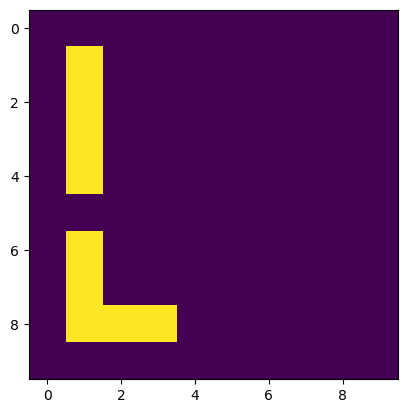

In [3]:
map_array = np.zeros(shape=(10, 10))
walls = [(1,1), (2, 1), (3, 1), (4, 1), (6, 1), (7, 1), (8, 1), (8, 2), (8, 3)]
good_cells = [(r, c) for r in range(10) for c in range(10) if (r, c) not in walls]
for wall in walls:
    r, c = wall
    map_array[r, c] = 1
plt.imshow(map_array)

In [4]:
# base_vector = M_space.init_random_vec()
# r_ssp = M_space.init_random_vec()
# c_ssp = M_space.init_random_vec()
# def get_ssp(r, c):
#     return M_space.bind(base_vector, M_space.frac_power(r_ssp, r), M_space.frac_power(c_ssp, c))


In [5]:
cell_ssps = [[M_space.init_random_vec() for _ in range(10)] for _ in range(10)]
def get_ssp(r, c):
    return cell_ssps[r][c]

In [6]:
all_cells = [(r, c) for r in range(10) for c in range(10)]
all_ssps = [get_ssp(r, c) for r in range(10) for c in range(10)]
all_ssp_mat = torch.concat(all_ssps, axis=1)
def get_sims(targ):
    r, c = targ
    targ_ssp = get_ssp(r, c)
    targ_e = ME_map.forwards(targ_ssp, normalize=False)
    all_e_mat = ME_map.forwards(all_ssp_mat, normalize=False)
    all_sims = E_space.similarity_R(targ_e, all_e_mat)
    return all_sims

In [7]:
def random_walk(map_array, good_cells, starting, steps):
    walk = [starting]
    pos = starting
    for step in range(steps):
        next_pos = random.choice([(pos[0]-1, pos[1]), (pos[0]+1, pos[1]), (pos[0], pos[1]-1), (pos[0], pos[1]+1)])
        while (next_pos not in good_cells):
            next_pos = random.choice([(pos[0]-1, pos[1]), (pos[0]+1, pos[1]), (pos[0], pos[1]-1), (pos[0], pos[1]+1)])
        pos = next_pos
        walk.append(pos)
    return walk

In [8]:
walk = random_walk(map_array, good_cells, (0, 0), 10000)
sum_event_code = E_space.init_zeros_vec()
for pos in tqdm.tqdm(walk):
    r, c = pos
    ssp = get_ssp(r, c)
    event = E_space.init_random_vec()
    sum_event_code = (sum_event_code * 0.9) + (event*(1-0.9))
    norm_event_code = E_space.normalize(sum_event_code)
    ME_map.learn(ssp, norm_event_code)
    MR_map.learn(ssp, event)

100%|██████████| 10001/10001 [03:21<00:00, 49.64it/s]


In [9]:
def softmax(values, const=1):
    tot = np.exp(np.sum(values/const))
    return np.exp(values/const)/tot

/tmp/ipykernel_7765/2494302061.py:4: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  sims = np.array(get_sims(targ)).flatten()


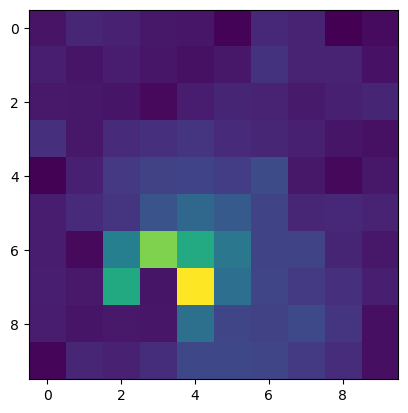

In [15]:
similarity_matrix = np.zeros(shape=(10, 10))
targ = (7, 3)
t = all_cells.index(targ)
sims = np.array(get_sims(targ)).flatten()
sims[t] = 0
sims = list(sims)
for i in range(100):
    r, c = all_cells[i]
    sim = sims[i]
    similarity_matrix[r, c] = sim
plt.imshow(similarity_matrix)

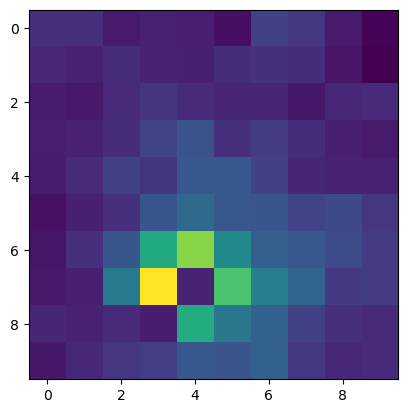

In [11]:
plt.imshow(similarity_matrix)